In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 1
## 1.1

In [ ]:
# Load data, shape: (256 samples, 10 channels, 300 trials)
mat = loadmat('responses.mat')
responses = mat['responses']

# Calculate time vector for 256 Hz sampling rate
fs = 256
n_samples = responses.shape[0]
t = np.arange(n_samples) / fs

# Electrode labels
electrodes = {0: 'Fz', 1: 'C4', 2: 'Cz', 3: 'C3', 4: 'P4', 5: 'Pz', 6: 'P3', 7: 'PO8', 8: 'Oz', 9: 'PO7'}


## 1.2

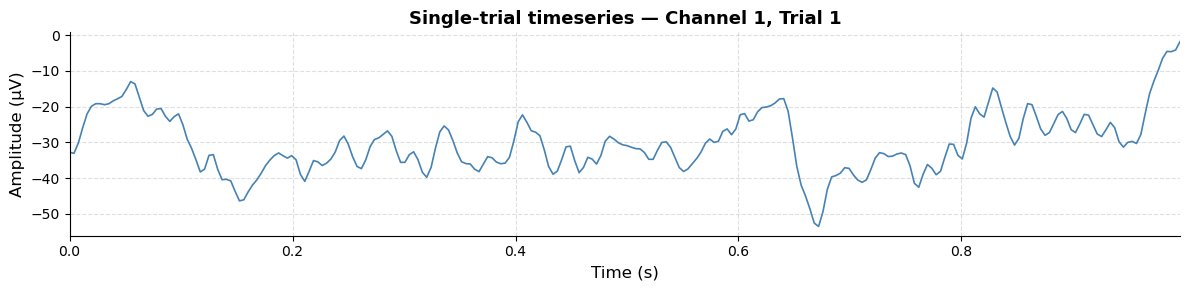

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, responses[:, 0, 0], color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Single-trial timeseries — Channel 1, Trial 1', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 1.2

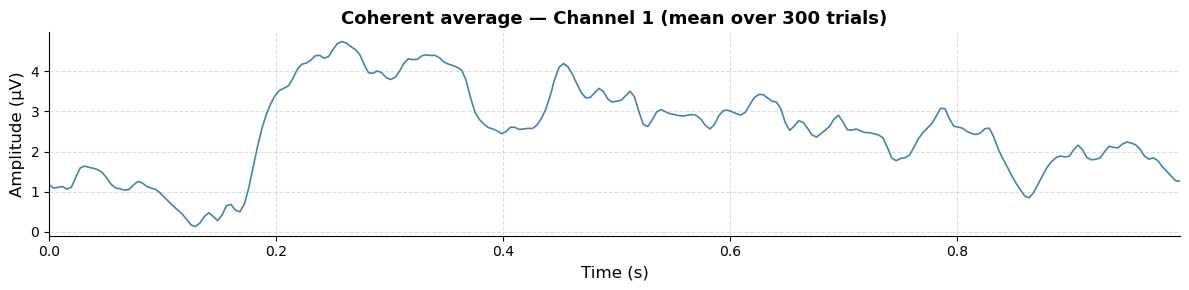

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, responses[:, 0, :].mean(axis=1), color='steelblue', linewidth=1.2)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Coherent average — Channel 1 (mean over 300 trials)', fontsize=13, fontweight='bold')
ax.set_xlim(t[0], t[-1])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 2
## 2.1

In [ ]:
import numpy.fft as fft

# Coherent average across trials: (256, 10)
avg = responses.mean(axis=2)

# Hamming window over time axis, applied per channel
window = np.hamming(n_samples)
avg_windowed = avg * window[:, np.newaxis]

# FFT per channel, keep positive frequencies
fft_coeffs = fft.rfft(avg_windowed, axis=0)
freqs = fft.rfftfreq(n_samples, d=1/fs)


## 2.2 - 2.3

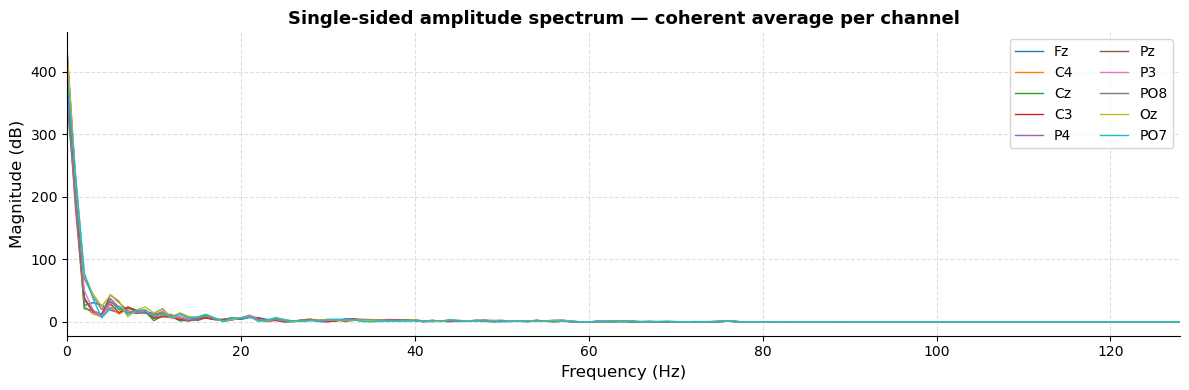

In [ ]:
amplitude_db = np.abs(fft_coeffs)

fig, ax = plt.subplots(figsize=(12, 4))
for ch in range(amplitude_db.shape[1]):
    ax.plot(freqs, amplitude_db[:, ch], linewidth=1.0, label=electrodes[ch])
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Magnitude (dB)", fontsize=12)
ax.set_title("Single-sided amplitude spectrum — coherent average per channel", fontsize=13, fontweight="bold")
ax.set_xlim(0, freqs[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()


# 3
## 3.1